In [3]:
import os
import sys
from os.path import join

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
import torch
import torch.multiprocessing as mp
from torch.distributed import init_process_group, destroy_process_group
from torch.utils.data.distributed import DistributedSampler
from torch.utils.data import DataLoader, Subset
from astropy.io import fits
import pyxis.torch as pxt
import pyxis as px

from networks import ForkCNN
from train import (
    load_model,
    apply_noise,
    predict,
    estimate_density,
    sample_density,
    sample_magnitudes,
    _load_rmag_snr_relation
)
import config
from utils import (
    denormalize,
    make_corner_plot,
)

stem = 'CNN-CNN-flow_all_params_unif_snr'
data_dir = '/ocean/projects/phy250048p/shared/datasets/test_1m_low_hlr'
samp_dir = '/ocean/projects/phy250048p/shared/samples/samples_test_1m_low_hlr.csv'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = f'/ocean/projects/phy250048p/shared/models/{stem}/'
loss_dir = '/ocean/projects/phy250048p/shared/models/losses/'
results_dir = '/ocean/projects/phy250048p/shared/results/'
cache_dir = '/ocean/projects/phy250048p/shared/cache/'

In [4]:
plt.rcParams.update({"text.usetex": False, "font.family": "serif", "figure.dpi": 300})
os.makedirs(join(fig_dir, stem), exist_ok=True)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
model_file = join(model_dir, f'{stem}180')
model = load_model(mode=1, path=model_file,strict=True, assign=True, device=device)

In [9]:
# Get data loader
bs = 100
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)
nsub = 10000
subset = Subset(test_ds, np.arange(0, nsub))
sub_dl = DataLoader(subset,
                    batch_size=bs,
                    pin_memory=False,
                    shuffle=False,)

In [12]:
model.eval()
trues = []
latents = []
# rmag = sample_magnitudes(nsub, m_min=15, m_max=23)
# a, b = _load_rmag_snr_relation()
# log_snr = (rmag - b) / a
# snrs = torch.from_numpy(10**log_snr).float().to(device)
snrs = torch.rand((nsub,), device=device)*995 + 5
with torch.no_grad():
    for i, batch in enumerate(sub_dl):
        snr = snrs[i*bs:(i+1)*bs]
        img = apply_noise(batch['img'].float().to(device), snr, device=device)
        spec = apply_noise(batch['spec'].float().to(device), snr, device=device)
        fid = batch['fid_pars'].float().to(device)
        latent = model.extract_latent(img, spec, fid)
        latents.append(latent.detach().cpu().numpy())
        trues.append(fid.cpu().numpy())
trues = np.vstack(trues)
latents = np.vstack(latents)
snrs = snrs.cpu().numpy()

In [13]:
latents.shape

(10000, 8)

Removed no burn in


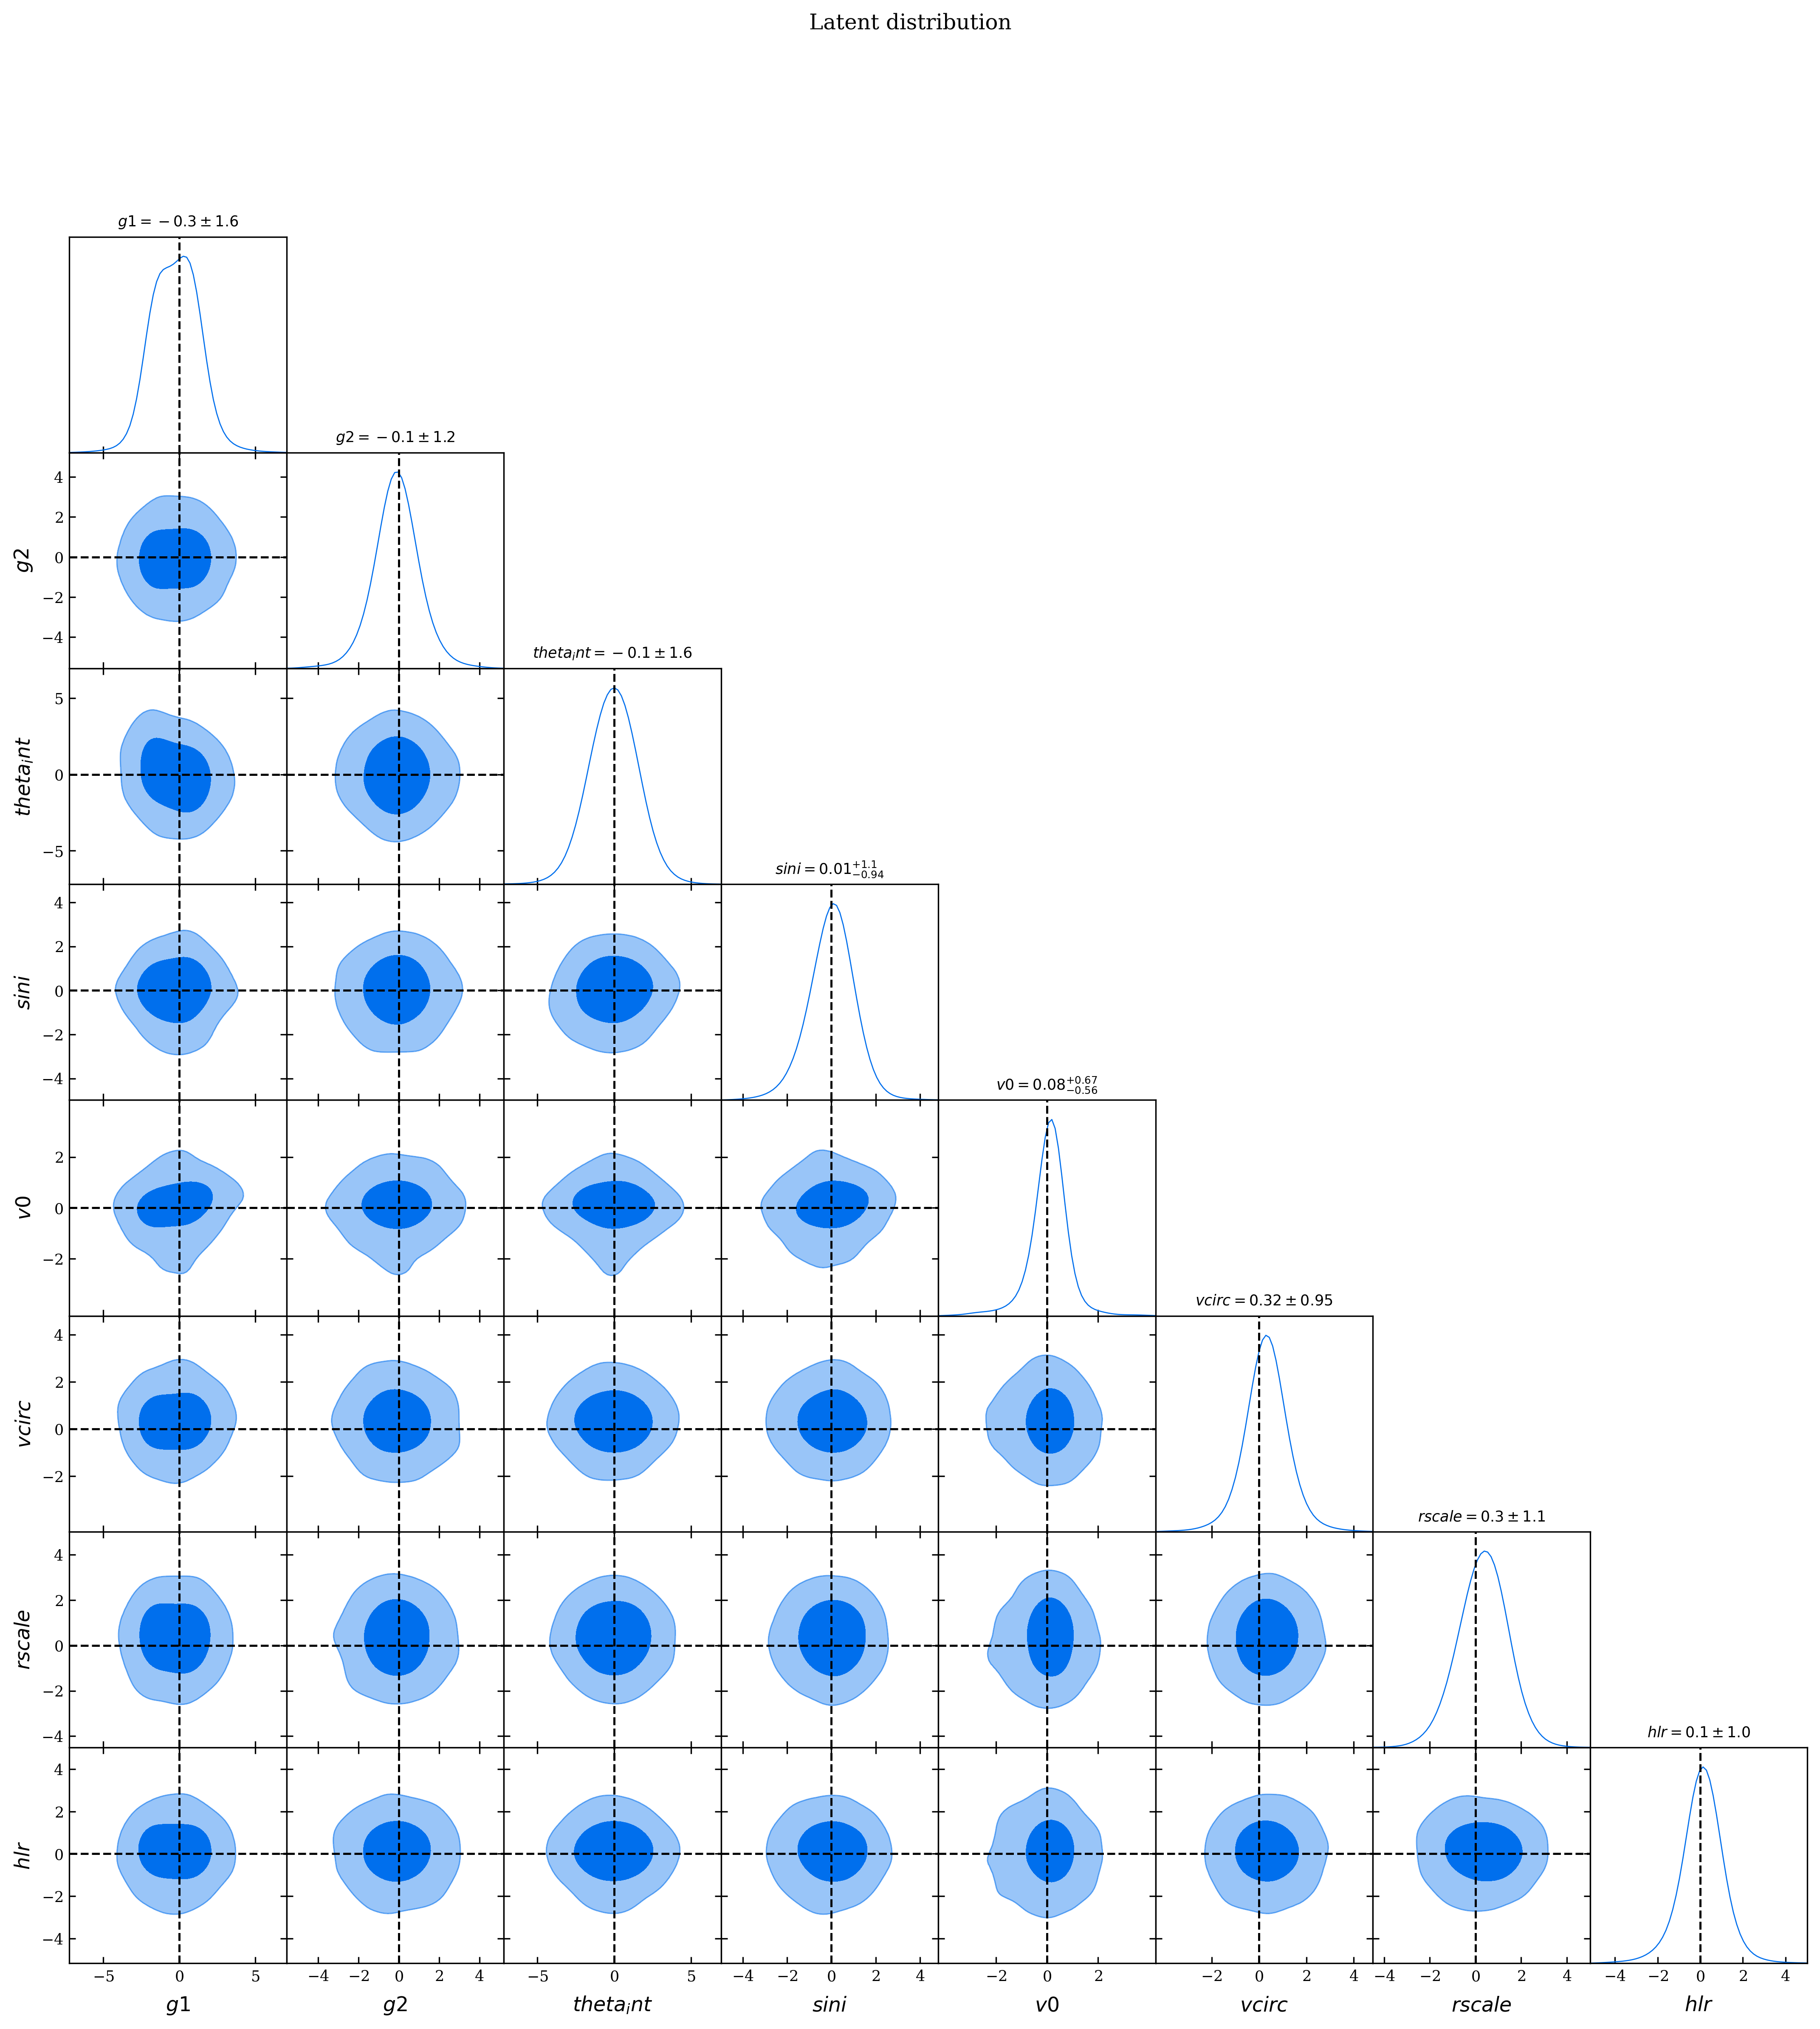

In [14]:
fig, _, _ = make_corner_plot(
    latents,
    truth=np.zeros((8)),
    labels=config.train['feature_names'],
    suptitle=f'Latent distribution',
)
fig.savefig(join(fig_dir, stem, f'latent_distribution.png'), dpi=300)